In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# data load

test_df = pd.read_csv(r"C:\Users\Adhithya Raviprakash\OneDrive\Documents\GitHub\Auto-Pulse\data\processed\fd001_test_processed.csv")

drop_cols = ['engine_id', 'cycle']

X_test = test_df.drop(drop_cols + ['RUL'], axis=1)
y_test = test_df['RUL']

In [3]:
#Load Saved Models

with open(r"C:\Users\Adhithya Raviprakash\OneDrive\Documents\GitHub\Auto-Pulse\models\random_forest_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open(r"C:\Users\Adhithya Raviprakash\OneDrive\Documents\GitHub\Auto-Pulse\models\xgboost_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

In [4]:
#Generate Predictions

rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

In [5]:
#Metrics Comparision

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "MAE": [
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "R2": [
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results

,Model,RMSE,MAE,R2
0,Random Forest,13.091069,9.557411,0.797706
1,XGBoost,12.072981,8.744183,0.827947


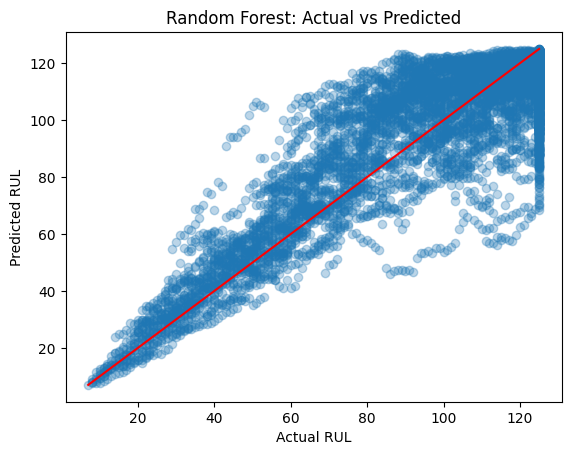

In [6]:
#Actual vs Predicted Plot : Random Forest

plt.figure()
plt.scatter(y_test, rf_pred, alpha=0.3)

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')  # perfect prediction line

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

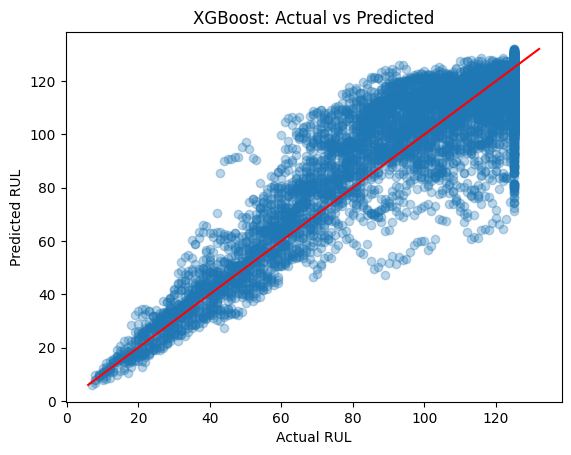

In [7]:
#Actual vs Predicted Plot : XGBoost

plt.figure()
plt.scatter(y_test, xgb_pred, alpha=0.3)

min_val = min(y_test.min(), xgb_pred.min())
max_val = max(y_test.max(), xgb_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')  # perfect prediction line

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

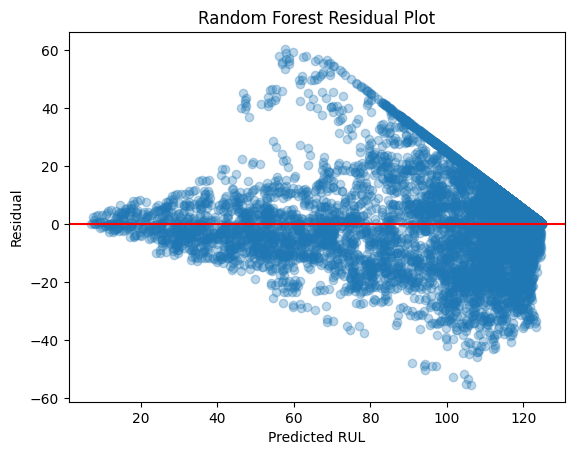

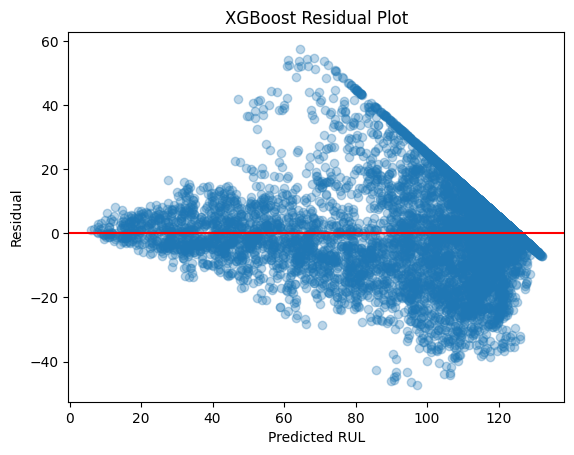

In [8]:
#Residual Analysis

rf_residuals = y_test - rf_pred
xgb_residuals = y_test - xgb_pred

#RF Residuals

plt.figure()
plt.scatter(rf_pred, rf_residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("Random Forest Residual Plot")
plt.show()

#XGB Residuals

plt.figure()
plt.scatter(xgb_pred, xgb_residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("XGBoost Residual Plot")
plt.show()

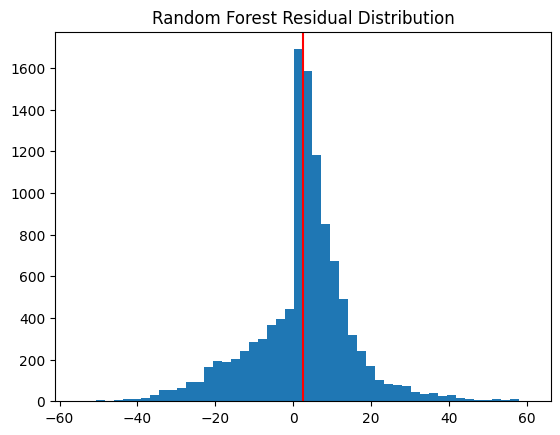

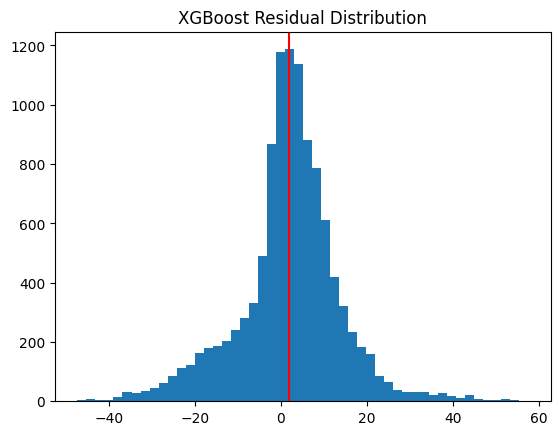

In [9]:
#Error Distribution

#RF Error Distribution

plt.figure()
plt.hist(rf_residuals, bins=50)
plt.axvline(np.mean(rf_residuals), color='red')
plt.title("Random Forest Residual Distribution")
plt.show()

#XGB Error Distribution

plt.figure()
plt.hist(xgb_residuals, bins=50)
plt.axvline(np.mean(xgb_residuals), color='red')
plt.title("XGBoost Residual Distribution")
plt.show()

In [10]:
#Performance Near Failure

failure_region = y_test <= 30

print("Random Forest - Near Failure RMSE:",
      np.sqrt(mean_squared_error(y_test[failure_region],
                                 rf_pred[failure_region])))

print("XGBoost - Near Failure RMSE:",
      np.sqrt(mean_squared_error(y_test[failure_region],
                                 xgb_pred[failure_region])))

print("Percentage Error Near Failure (RF):", np.mean(np.abs((y_test[failure_region] - rf_pred[failure_region]) / y_test[failure_region])) * 100)

print("Percentage Error Near Failure (XGB):", np.mean(np.abs((y_test[failure_region] - xgb_pred[failure_region]) / y_test[failure_region])) * 100)

Random Forest - Near Failure RMSE: 5.862656726669336
XGBoost - Near Failure RMSE: 4.429576408163846
Percentage Error Near Failure (RF): 19.360189634403863
Percentage Error Near Failure (XGB): 15.823951755632477


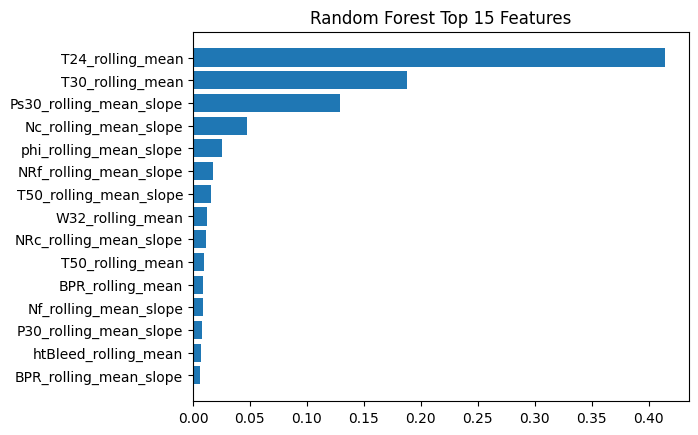

In [11]:
#Feature Importance For RF

rf_importance = rf_model.feature_importances_
features = X_test.columns

indices = np.argsort(rf_importance)[-15:]

plt.figure()
plt.barh(range(len(indices)), rf_importance[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("Random Forest Top 15 Features")
plt.show()

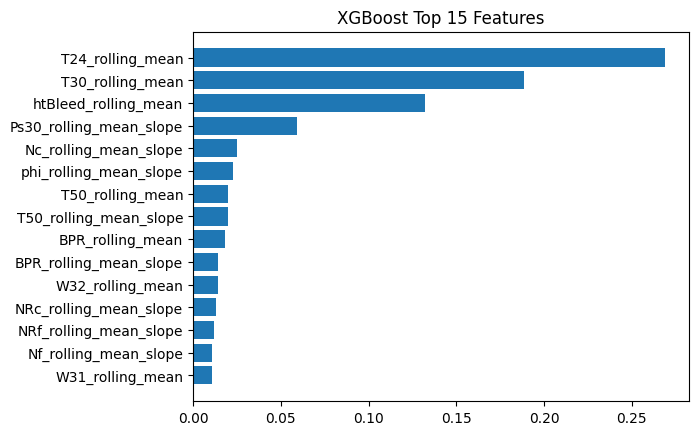

In [12]:
#Feature Importance For XGBoost

xgb_importance = xgb_model.feature_importances_

indices = np.argsort(xgb_importance)[-15:]

plt.figure()
plt.barh(range(len(indices)), xgb_importance[indices])
plt.yticks(range(len(indices)), features[indices])
plt.title("XGBoost Top 15 Features")
plt.show()

In [13]:
#Bias Check Early Vs Late Predictions

rf_bias = np.mean(rf_pred - y_test)
xgb_bias = np.mean(xgb_pred - y_test)

print("RF Average Bias:", rf_bias)
print("XGB Average Bias:", xgb_bias)

RF Average Bias: -2.521827425487344
XGB Average Bias: -1.9050056488568585


In [16]:
#Correlation Analysis

print("Correlation RF:", np.corrcoef(test_df["RUL"], rf_pred)[0,1])
print("Correlation XGBoost:", np.corrcoef(test_df["RUL"], xgb_pred)[0,1])

Correlation RF: 0.8974871520575002
Correlation XGBoost: 0.9122671656621283


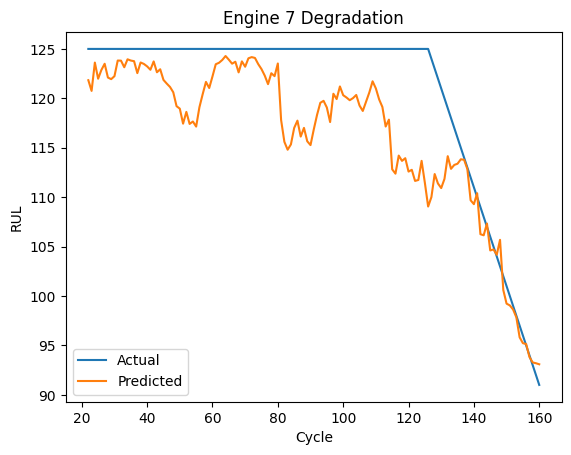

In [23]:
#Engine Wise Degradation Plot for RF

engine_id = 7

engine_data = test_df[test_df["engine_id"] == engine_id]
X_engine = engine_data.drop(["engine_id","cycle","RUL"], axis=1)

pred_engine = rf_model.predict(X_engine)

plt.figure()
plt.plot(engine_data["cycle"], engine_data["RUL"], label="Actual")
plt.plot(engine_data["cycle"], pred_engine, label="Predicted")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title(f"Engine {engine_id} Degradation")
plt.legend()
plt.show()

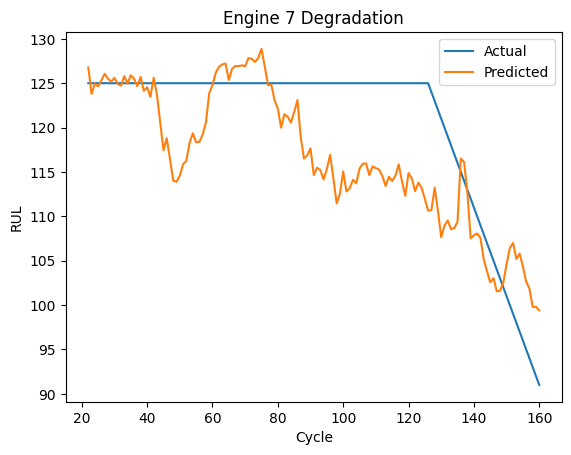

In [28]:
#Engine Wise Degradation Plot for XGBoost

engine_id = 7

engine_data = test_df[test_df["engine_id"] == engine_id]
X_engine = engine_data.drop(["engine_id","cycle","RUL"], axis=1)

pred_engine = xgb_model.predict(X_engine)

plt.figure()
plt.plot(engine_data["cycle"], engine_data["RUL"], label="Actual")
plt.plot(engine_data["cycle"], pred_engine, label="Predicted")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title(f"Engine {engine_id} Degradation")
plt.legend()
plt.show()